# Master's Thesis: Engine Health Anomaly Detection
**Student:** ASHLO SHAJU  
**Study Programme:** Applied Informatics  
**Research Goal:** Evaluating Isolation Forest, LOF, One-Class SVM, and LSTM-Autoencoder for **real-time engine health monitoring** and early failure detection.

## Focus: ENGINE HEALTH ONLY
This study concentrates exclusively on **Engine Failure Detection** using OBD-II engine sensor monitoring.


In [55]:
# Install PyOD for Isolation Forest, LOF, and One-Class SVM
!pip install pyod --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from math import pi

from pandas.plotting import parallel_coordinates

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

# PyOD Models
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ocsvm import OCSVM

# TensorFlow for Autoencoder
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

## Phase 2: Data Acquisition & Preparation (Task 2)
Here we load the Kaggle engine_data.csv dataset containing 19,535 real-world engine sensor samples.

**Dataset Source:** Kaggle - Automotive Engine Health Dataset  
**Features:** Engine RPM, Lubricant Oil Pressure, Fuel Pressure, Coolant Pressure, Lubricant Oil Temperature, Coolant Temperature  
**Target:** Engine Condition (0 = Normal operation, 1 = Fault detected)

In [ ]:
# Load the Kaggle vehicle_fault_dataset_smart.csv dataset
print("--- Loading Dataset ---")
try:
    engine_df = pd.read_csv('vehicle_fault_dataset_smart.csv')
    print(f"✅ Successfully loaded vehicle_fault_dataset_smart.csv")
    print(f"   Shape: {engine_df.shape}")
    print(f"   Total Columns: {len(engine_df.columns)}")
    print(f"\n📊 Database Overview:")
    print(f"   Total Observations: {len(engine_df)}")
    print(f"   Vehicles: {engine_df['vehicle_id'].nunique()}")
    print(f"   Brands: {engine_df['brand'].nunique()}")
except FileNotFoundError:
    print("❌ vehicle_fault_dataset_smart.csv not found. Please ensure the file is in the working directory.")
    raise

display(engine_df.head(3))
print("\nFirst 3 rows of the dataset:")

--- Loading Dataset ---
✅ Successfully loaded vehicle_fault_dataset_smart.csv
   Shape: (30000, 41)
   Total Columns: 41

📊 Database Overview:
   Total Observations: 30000
   Vehicles: 250
   Brands: 6


,vehicle_id,brand,timestamp,odometer_reading,engine_temp_c,engine_rpm,oil_pressure_psi,coolant_temp_c,fuel_level_percent,fuel_consumption_lph,...,vehicle_speed_kph,ambient_temp_c,humidity_percent,gps_latitude,gps_longitude,engine_failure_imminent,brake_issue_imminent,battery_issue_imminent,failure_date,failure_type
0,VEH0000,Audi,01/01/23 00:00,10000.0,99.233329,2652.708184,58.939125,91.998869,100.0,7.142203,...,66.680239,13.172355,75.767116,-37.754568,144.995940,0,0,0,01/01/50 00:00,No Failure
1,VEH0000,Audi,01/01/23 00:05,10000.5,91.772613,2060.971080,54.617212,89.541509,99.9,5.118227,...,76.909624,33.177809,53.643182,-37.788936,145.013998,0,0,1,24/01/23 00:05,Battery Failure
2,VEH0000,Honda,01/01/23 00:10,10001.0,70.383392,706.086291,33.974923,64.808222,99.8,1.044961,...,2.496031,14.873139,33.527212,-37.745629,144.807616,0,0,1,23/01/23 00:10,Battery Failure


## Phase 2b: Exploratory Data Analysis (Dataset Analysis)
Before applying sliding windows and machine learning models, we must understand the statistical distribution of the vehicle sensor signals.

This section performs a fundamental dataset analysis:
1. **Data Info (`info()`):** Checks data types (e.g., floats/integers) and total memory usage.
2. **Data Description (`describe()`):** Provides statistical summaries (mean, std, min, max, quartiles). This is vital because anomalies (like an RPM spike) will often be visible when comparing the `max` value against the `75th percentile`.
3. **Missing Values:** Counts any missing sensor readings that could disrupt the real-time stream.

DATASET ANALYSIS: KAGGLE ENGINE HEALTH DATASET

--- 1. Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   vehicle_id               30000 non-null  str    
 1   brand                    30000 non-null  str    
 2   timestamp                30000 non-null  str    
 3   odometer_reading         30000 non-null  float64
 4   engine_temp_c            30000 non-null  float64
 5   engine_rpm               30000 non-null  float64
 6   oil_pressure_psi         30000 non-null  float64
 7   coolant_temp_c           30000 non-null  float64
 8   fuel_level_percent       30000 non-null  float64
 9   fuel_consumption_lph     30000 non-null  float64
 10  engine_load_percent      30000 non-null  float64
 11  throttle_pos_percent     30000 non-null  float64
 12  air_flow_rate_gps        30000 non-null  float64
 13  exhaust_gas

,count,mean,std,min,25%,50%,75%,max
odometer_reading,30000.0,17499.750000,4330.199187,10000.000000,13749.875000,17499.750000,21249.625000,24999.500000
engine_temp_c,30000.0,94.724980,14.411803,67.731633,81.247365,94.985198,107.038351,124.925404
engine_rpm,30000.0,2047.398885,935.875689,600.057974,1144.495720,2008.965825,2759.384692,3999.681734
oil_pressure_psi,30000.0,50.479373,9.797782,31.175397,42.296376,50.215142,57.791500,74.876772
coolant_temp_c,30000.0,89.731407,14.525186,59.914336,76.505017,90.010773,102.107553,122.314209
fuel_level_percent,30000.0,50.050000,28.867980,0.100000,25.075000,50.050000,75.025000,100.000000
fuel_consumption_lph,30000.0,5.951103,2.883337,0.517036,3.238880,5.998221,8.431810,11.969764
engine_load_percent,30000.0,49.476246,28.263673,5.007838,20.193696,49.944654,74.442885,99.993955
throttle_pos_percent,30000.0,49.498216,28.431354,0.252847,21.307804,49.997139,74.615401,104.823811
air_flow_rate_gps,30000.0,44.595708,22.805964,4.136867,22.292814,45.004921,64.527769,89.745239



--- 3. Missing Values Check ---
✅ No missing values found. The dataset is clean.

--- 4. Class Distribution ---
No target label column found. Unsupervised learning will be fully relied upon.




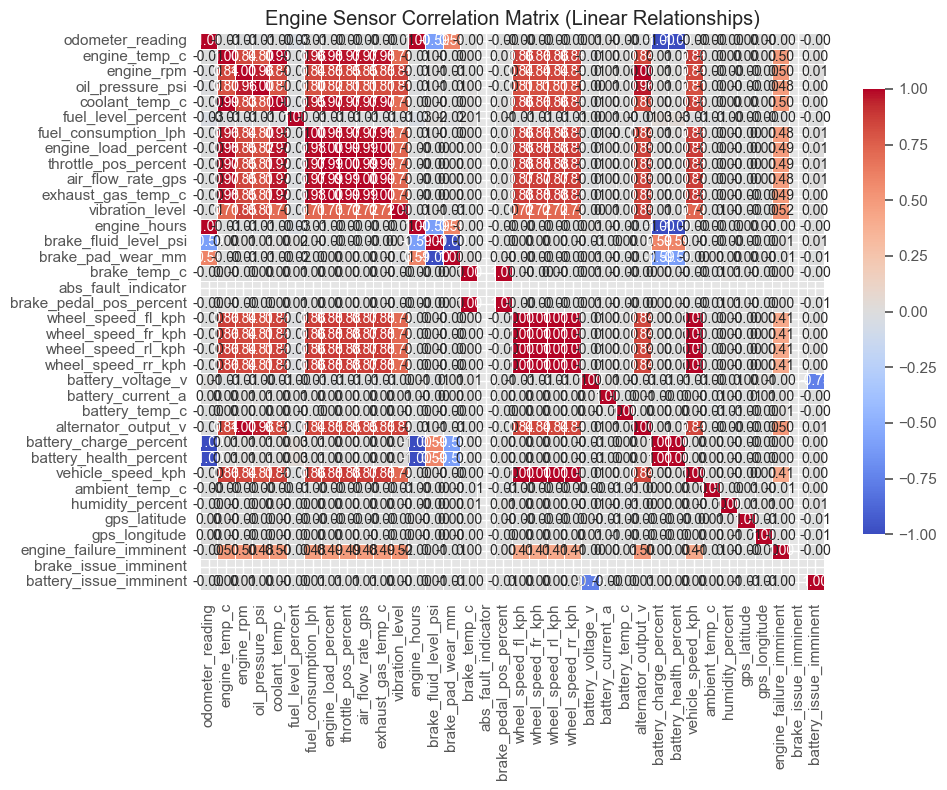

In [57]:
def analyze_dataset(df, dataset_name):
    print("="*60)
    print(f"DATASET ANALYSIS: {dataset_name.upper()}")
    print("="*60)

    # 1. Dataset Information (Data types and non-null counts)
    print(f"\n--- 1. Data Information ---")
    df.info()

    # 2. Statistical Description (Transposed for better readability)
    print(f"\n--- 2. Statistical Summary (Distribution) ---")
    display(df.describe().T)

    # 3. Missing Values Check
    print(f"\n--- 3. Missing Values Check ---")
    missing_vals = df.isnull().sum()
    if missing_vals.sum() == 0:
        print("✅ No missing values found. The dataset is clean.")
    else:
        print("⚠️ Missing values detected:")
        print(missing_vals[missing_vals > 0])

    # 4. Data Imbalance Check (If labels exist)
    label_cols =[col for col in df.columns if col.lower() in ['label', 'fault', 'anomaly', 'target', 'condition', 'engine condition']]
    if label_cols:
        target = label_cols[0]
        print(f"\n--- 4. Class Distribution ({target}) ---")
        class_dist = df[target].value_counts(normalize=True).mul(100).round(2)
        for class_val, pct in class_dist.items():
            print(f"   Class {int(class_val)}: {pct}%")
    else:
        print("\n--- 4. Class Distribution ---")
        print("No target label column found. Unsupervised learning will be fully relied upon.")

    print("\n" + "="*60 + "\n")

# Run analysis on the dataset
if 'engine_df' in locals():
    analyze_dataset(engine_df, "Kaggle Engine Health Dataset")

# Plot a correlation heatmap to see how sensors relate to each other
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation matrix
numeric_df = engine_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Engine Sensor Correlation Matrix (Linear Relationships)")
plt.tight_layout()
plt.show()

## Phase 2c: Advanced Exploratory Data Analysis (EDA) & Visualizations
To justify the use of our four anomaly detection algorithms (Isolation Forest, LOF, One-Class SVM, Autoencoder), we must visually explore the dataset.

This section generates 5 insightful visualizations:
1. **Time-Series Sensor Streaming:** Visualizing how signals (RPM, Temperature, Vibration) behave sequentially and where anomalies occur.
2. **Correlation Heatmap:** Identifying relationships between sensors (e.g., RPM and Torque). High correlation helps Autoencoders reconstruct normal behavior.
3. **Sensor Distributions (KDE Plots):** Checking if the data follows a normal distribution and observing the "tails" where anomalies live.
4. **Boxplots by Condition:** Proving visually that anomalous states have different median values or extreme outliers compared to normal driving.
5. **2D Decision Boundary Scatter:** Plotting two features against each other to visualize how algorithms like One-Class SVM will separate the classes.

## Phase 3: Dataset-Specific Preprocessing & Feature Engineering
Based on the Exploratory Data Analysis, our Kaggle engine_data.csv dataset contains 6 numeric sensor features and a binary fault label. To prepare this for the Autoencoder and PyOD models, we will:
1. **Isolate the Target:** Extract `Engine Condition` as a binary label (0 = Normal, 1 = Fault).
2. **Drop Non-Predictive Columns:** The dataset is already clean with no categorical columns requiring encoding.
3. **Scale Features:** Apply `StandardScaler` so that RPM (0-7000) does not dominate pressures (0-500) and temperatures (0-150) in the neural network.

In [58]:
# ========== PHASE 3: PREPROCESSING - ENGINE HEALTH FOCUS ==========
# Prepare the dataset for model training
# FOCUS: ENGINE HEALTH ONLY

df = engine_df.copy()

# 1. Create Binary Target Label: ENGINE HEALTH ONLY
# Target: engine_failure_imminent (0 = Healthy, 1 = Engine Fault)
y = df['engine_failure_imminent'].values
print(f"✅ Target Label Created (ENGINE HEALTH ONLY):")
print(f"   Healthy samples (0): {sum(y==0)} ({100*sum(y==0)/len(y):.1f}%)")
print(f"   Engine Fault samples (1): {sum(y==1)} ({100*sum(y==1)/len(y):.1f}%)")

# 2. Select key ENGINE SENSOR features (7 sensors)
# Features: Engine RPM, Oil Pressure, Coolant Temp, Engine Load, Throttle Position, Vibration, Fuel Consumption
sensor_features = [
    'engine_rpm',
    'oil_pressure_psi',
    'coolant_temp_c',
    'engine_load_percent',
    'throttle_pos_percent',
    'vibration_level',
    'fuel_consumption_lph'
]

# 3. Filter to available columns
available_features = [f for f in sensor_features if f in df.columns]

# 4. Extract features and handle missing/infinite values
X = df[available_features].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print(f"   Initial Samples: {len(X)}")

# 4b. OUTLIER REMOVAL using IQR Method (from thesis proposal)
# This removes statistical outliers that could skew model training
samples_before = len(X)
for col in available_features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Keep only rows where this column is within bounds
    X = X[X[col].between(lower_bound, upper_bound)]

samples_after = len(X)
print(f"   Outliers Removed (IQR method): {samples_before - samples_after} samples")
print(f"   Remaining Samples: {samples_after}")

# ========== BUG FIX: CORRECT LABEL ALIGNMENT ==========
# After IQR filtering, use the filtered indices to align y correctly
# (using y = y[:len(X)] was wrong because indices don't align after filtering)
y = df.loc[X.index, 'engine_failure_imminent'].values

# 5. Standardize all sensor features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Create feature names reference
feature_names = available_features

print(f"\n✅ Preprocessing Complete:")
print(f"   Final Samples (after outlier removal): {len(X_scaled)}")
print(f"   Feature Matrix Shape: {X_scaled.shape}")
print(f"   Features: {list(feature_names)}")


✅ Target Label Created (ENGINE HEALTH ONLY):
   Healthy samples (0): 26722 (89.1%)
   Engine Fault samples (1): 3278 (10.9%)
   Initial Samples: 30000
   Outliers Removed (IQR method): 0 samples
   Remaining Samples: 30000

✅ Preprocessing Complete:
   Final Samples (after outlier removal): 30000
   Feature Matrix Shape: (30000, 7)
   Features: ['engine_rpm', 'oil_pressure_psi', 'coolant_temp_c', 'engine_load_percent', 'throttle_pos_percent', 'vibration_level', 'fuel_consumption_lph']
